In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:/RetailPulse_Project/data/cleaned/online_retail_eda_ready_big.csv",parse_dates=["InvoiceDate"])

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,MonthName,Day,Weekday,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,1,Tuesday,7


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    779425 non-null  int64         
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   UnitPrice    779425 non-null  float64       
 6   CustomerID   779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   TotalPrice   779425 non-null  float64       
 9   Year         779425 non-null  int64         
 10  Month        779425 non-null  int64         
 11  MonthName    779425 non-null  str           
 12  Day          779425 non-null  int64         
 13  Weekday      779425 non-null  str           
 14  Hour         779425 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(6), s

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month',
       'MonthName', 'Day', 'Weekday', 'Hour'],
      dtype='str')

In [6]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [7]:
df["CustomerID"].dtype

dtype('int64')

In [8]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days = 1)
print(reference_date)

2011-12-10 12:50:00


In [9]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate" : lambda x : (reference_date - x.max()).days,
    "InvoiceNo" : "nunique",
    "TotalPrice" : "sum"})
rfm.columns = ["Recency","Frequency","Moentary"]
rfm.head()

,Recency,Frequency,Moentary
CustomerID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [10]:
rfm.shape

(5878, 3)

In [11]:
rfm.describe()

,Recency,Frequency,Moentary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [12]:
rfm.rename(columns={"Moentary": "Monetary"}, inplace=True)

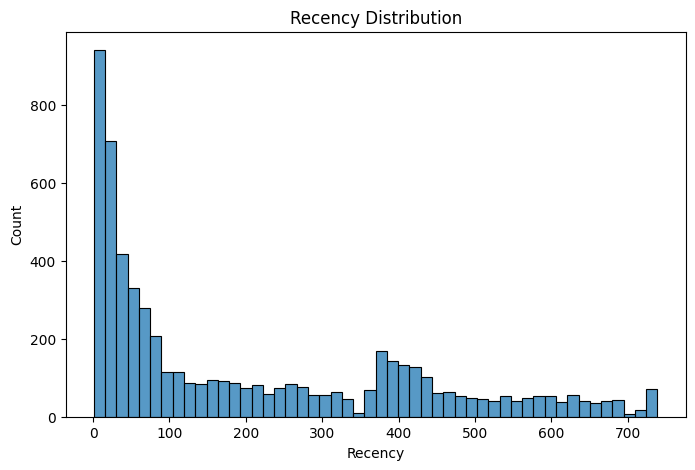

In [13]:
plt.figure(figsize = (8,5))
sns.histplot(rfm["Recency"],bins = 50)
plt.title("Recency Distribution")
plt.show()

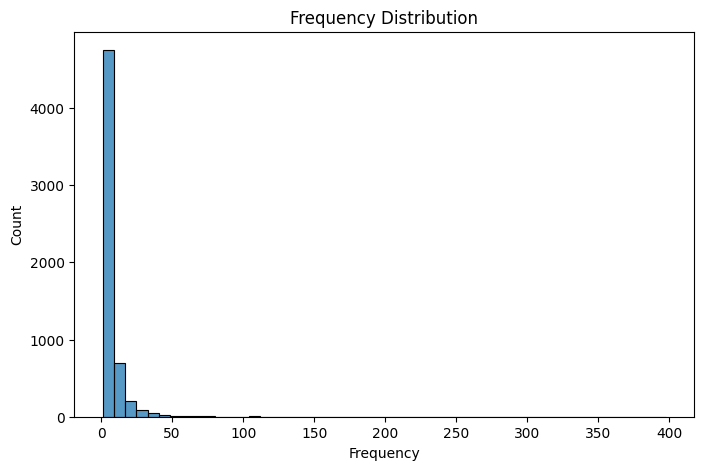

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Frequency"], bins=50)
plt.title("Frequency Distribution")
plt.show()

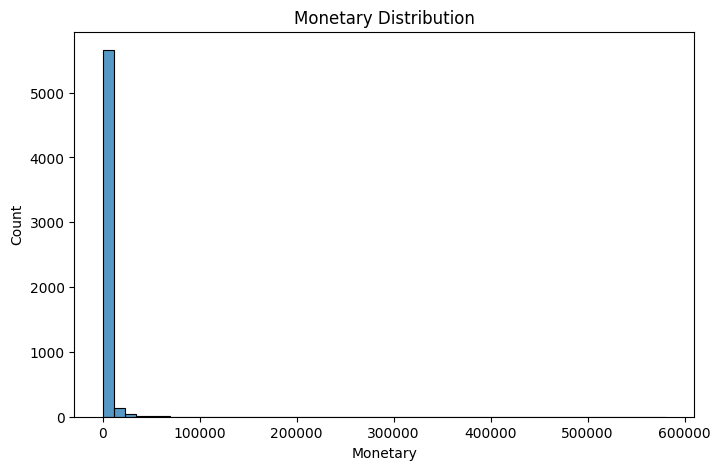

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Monetary"], bins=50)
plt.title("Monetary Distribution")
plt.show()

In [16]:
rfm["R_Score"] = pd.qcut(rfm["Recency"],q = 4,labels = [4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method = "first"),q = 4,labels = [1,2,3,4],duplicates="drop")
rfm["M_Score"] = pd.qcut(rfm["Monetary"],q = 4,labels = [1,2,3,4],duplicates = "drop")

In [17]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346,326,12,77556.46,2,4,4
12347,2,8,4921.53,4,4,4
12348,75,5,2019.40,3,3,3
12349,19,4,4428.69,4,3,4
12350,310,1,334.40,2,1,1


In [18]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,12,77556.46,2,4,4,244
12347,2,8,4921.53,4,4,4,444
12348,75,5,2019.40,3,3,3,333
12349,19,4,4428.69,4,3,4,434
12350,310,1,334.40,2,1,1,211


In [19]:
def segment_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champion"

    elif row["F_Score"] >= 3 and row["R_Score"] >= 3:
        return "Loyal Customer"

    elif row["M_Score"] >= 4:
        return "Big Spender"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost Customer"

    else:
        return "Others"


rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346,326,12,77556.46,2,4,4,244,Big Spender
12347,2,8,4921.53,4,4,4,444,Champion
12348,75,5,2019.40,3,3,3,333,Loyal Customer
12349,19,4,4428.69,4,3,4,434,Loyal Customer
12350,310,1,334.40,2,1,1,211,Lost Customer


In [20]:
rfm["Segment"].value_counts()

Segment
Lost Customer     2008
Loyal Customer    1400
Others             871
Champion           659
At Risk            644
Big Spender        296
Name: count, dtype: int64

In [21]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

segment_revenue

Segment
Champion          9404593.604
Loyal Customer    3924940.995
Big Spender       1958698.876
Lost Customer      856315.432
At Risk            730979.480
Others             499275.881
Name: Monetary, dtype: float64

In [22]:
segment_avg = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

segment_avg

Segment
Champion          14271.006986
Big Spender        6617.225932
Loyal Customer     2803.529282
At Risk            1135.061304
Others              573.221448
Lost Customer       426.451908
Name: Monetary, dtype: float64

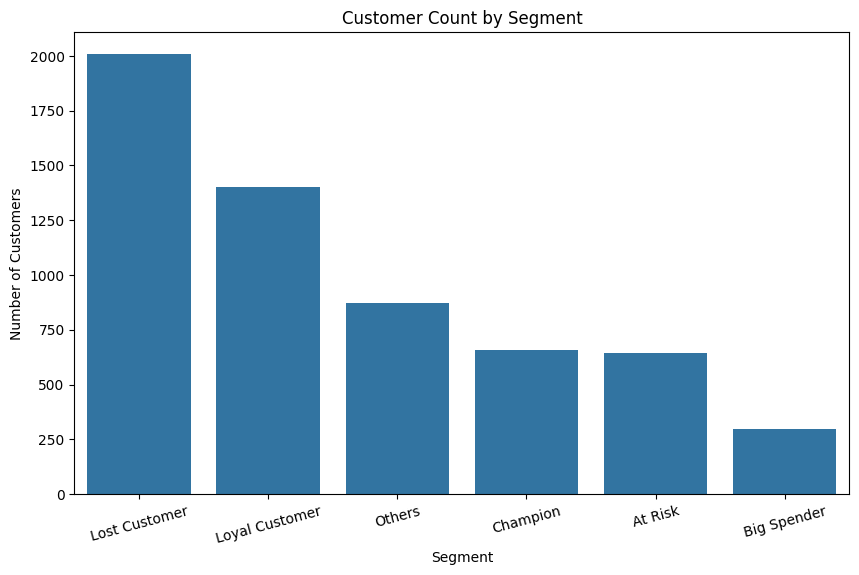

In [23]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Count by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

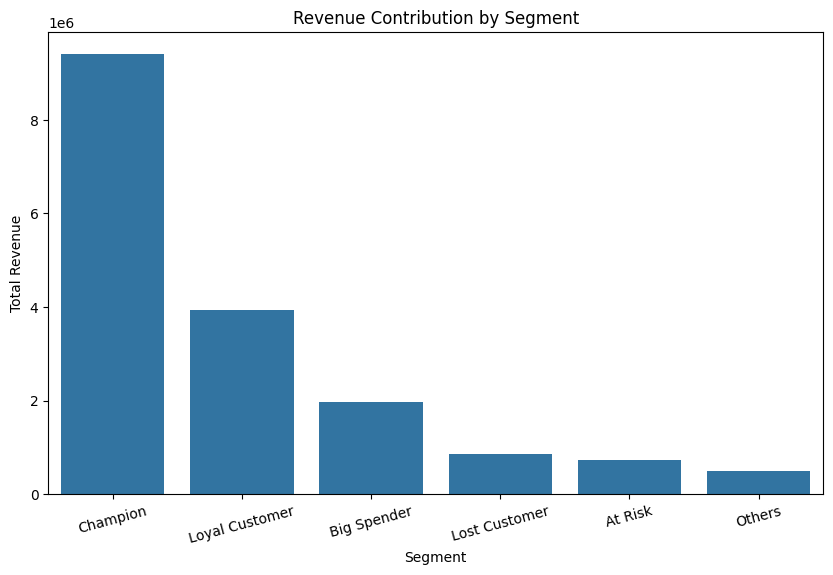

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=15)

plt.show()

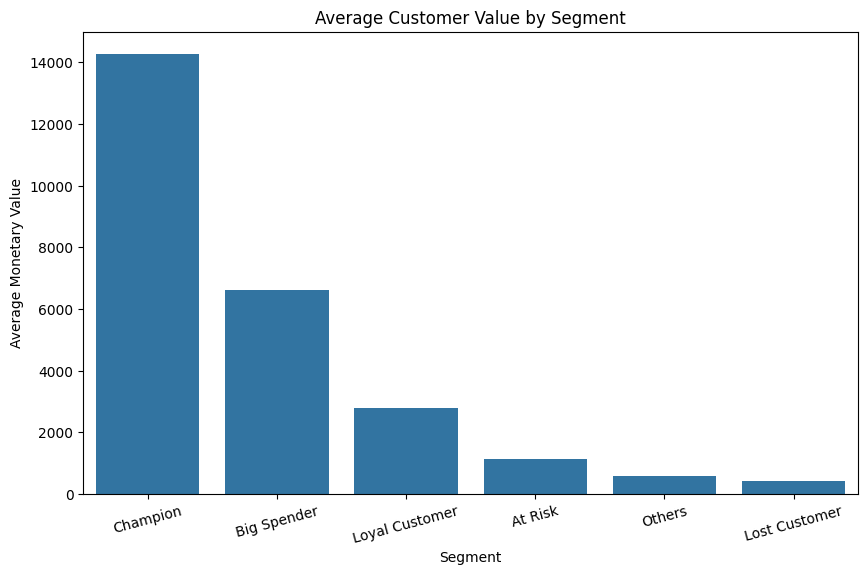

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=segment_avg.index,
    y=segment_avg.values
)

plt.title("Average Customer Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Monetary Value")

plt.xticks(rotation=15)

plt.show()

In [31]:
rfm.to_csv(r"E:/RetailPulse_Project/data/cleaned/rfm_customer_segment_large.csv",index = True)